
Training model A...
Epoch 1/5 completed
Epoch 2/5 completed
Epoch 3/5 completed
Epoch 4/5 completed
Epoch 5/5 completed

Training model B...
Epoch 1/5 completed
Epoch 2/5 completed
Epoch 3/5 completed
Epoch 4/5 completed
Epoch 5/5 completed

====== Test Accuracies ======
Model A:      97.24%
Model B:      96.77%
Merged model: 95.76%

Training full-data model...
Epoch 1/5 completed
Epoch 2/5 completed
Epoch 3/5 completed
Epoch 4/5 completed
Epoch 5/5 completed
Full-data model: 97.73%
Saved plot: mlp_lambda_curve.png


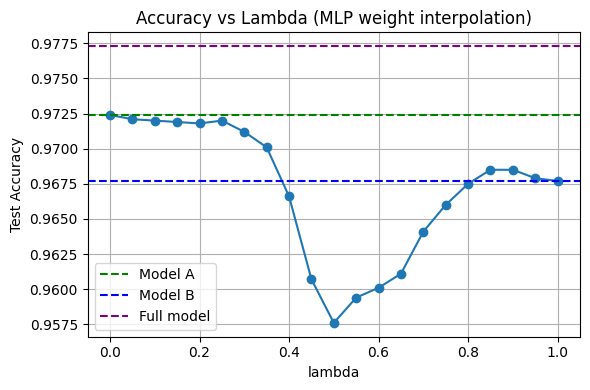

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# 1. MLP MODEL (PyTorch version of paper’s MLP)
# ============================================
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 10)
        self.relu = nn.ReLU()
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return self.logsoftmax(x)

# ====================================
# 2. Load MNIST and split into 2 sets
# ====================================
transform = transforms.ToTensor()
dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

N = len(dataset)
half = N // 2
subsetA, subsetB = random_split(dataset, [half, N - half])

test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=512)

# ============================
# 3. Training function
# ============================

def train_model(model, dataset, epochs=5, lr=1e-3):
    loader = DataLoader(dataset, batch_size=128, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(epochs):
        for x, y in loader:
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

        print(f"Epoch {epoch+1}/{epochs} completed")

    return model

# ============================
# 4. Train two disjoint models
# ============================
print("\nTraining model A...")
modelA = train_model(MLP(), subsetA, epochs=5)

print("\nTraining model B...")
modelB = train_model(MLP(), subsetB, epochs=5)

stateA = modelA.state_dict()
stateB = modelB.state_dict()

# ========================================
# 5. Naive merge: elementwise weight mean
# ========================================
merged_state = {}

for key in stateA:
    merged_state[key] = (stateA[key] + stateB[key]) / 2.0

merged_model = MLP()
merged_model.load_state_dict(merged_state)

# ============================
# 6. Evaluation helper
# ============================
def evaluate(model):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            out = model(x)
            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

accA = evaluate(modelA)
accB = evaluate(modelB)
accMerged = evaluate(merged_model)

print("\n====== Test Accuracies ======")
print(f"Model A:      {accA*100:.2f}%")
print(f"Model B:      {accB*100:.2f}%")
print(f"Merged model: {accMerged*100:.2f}%")

# =============================================
# 7. Optional: Train single model on full data
# =============================================
print("\nTraining full-data model...")
modelFull = train_model(MLP(), dataset, epochs=5)
accFull = evaluate(modelFull)
print(f"Full-data model: {accFull*100:.2f}%")

# =============================================
# 8. Lambda interpolation sweep
# =============================================
lambdas = np.linspace(0, 1, 21)
accs = []

for lam in lambdas:
    interp_state = {}
    for key in stateA:
        interp_state[key] = (1-lam)*stateA[key] + lam*stateB[key]
    m = MLP()
    m.load_state_dict(interp_state)
    accs.append(evaluate(m))

plt.figure(figsize=(6,4))
plt.plot(lambdas, accs, marker='o')
plt.axhline(accA, color='green', linestyle='--', label="Model A")
plt.axhline(accB, color='blue', linestyle='--', label="Model B")
plt.axhline(accFull, color='purple', linestyle='--', label="Full model")
plt.title("Accuracy vs Lambda (MLP weight interpolation)")
plt.xlabel("lambda")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("mlp_lambda_curve.png", dpi=150)
print("Saved plot: mlp_lambda_curve.png")

